##Problem Statement:

The objective of this project is to build a machine learning model to predict the **market value of football players** using the FIFA dataset. The prediction is based on player attributes such as physical characteristics, technical skills, and performance metrics. The project also analyzes the effect of **PCA and hyperparameter tuning** on model performance.

In [30]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
#Loading the data datasets

df = pd.read_csv("/content/player_stats.csv", encoding='latin1')

In [9]:
df.head()

,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Cristian Castro Devenish,Colombia,192,84,22,Atl. Nacional,55,43,NaN,68,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Silaldo Taffarel,Brazil,181,80,31,Corinthians,69,70,NaN,56,...,65,62,48,46,12,15,14,8,14,$975.00
2,Thomas DÃ¤hne,Germany,193,84,29,Holstein Kiel,25,12,NaN,13,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Michael Sollbauer,Austria,187,86,33,SK Rapid Wien,46,48,NaN,66,...,25,13,22,19,10,10,8,14,9,$650.00
4,Diego Segovia,Uruguay,191,80,23,Independiente,14,8,NaN,14,...,9,10,16,5,61,59,62,64,64,$300.00


In [8]:
# Check shape (rows, columns)
df.shape

(5682, 41)

In [10]:
# Check data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5682 entries, 0 to 5681
Data columns (total 41 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   player          5682 non-null   object 
 1   country         5682 non-null   object 
 2   height          5682 non-null   int64  
 3   weight          5682 non-null   int64  
 4   age             5682 non-null   int64  
 5   club            5682 non-null   object 
 6   ball_control    5682 non-null   int64  
 7   dribbling       5682 non-null   int64  
 8   marking         0 non-null      float64
 9   slide_tackle    5682 non-null   int64  
 10  stand_tackle    5682 non-null   int64  
 11  aggression      5682 non-null   int64  
 12  reactions       5682 non-null   int64  
 13  att_position    5682 non-null   int64  
 14  interceptions   5682 non-null   int64  
 15  vision          5682 non-null   int64  
 16  composure       5682 non-null   int64  
 17  crossing        5682 non-null   i

In [11]:
# Statistical summary
df.describe()

,height,weight,age,ball_control,dribbling,marking,slide_tackle,stand_tackle,aggression,reactions,...,long_shots,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes
count,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,0.0,5682.000000,5682.000000,5682.000000,5682.000000,...,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.00000,5682.000000,5682.000000,5682.000000
mean,181.670539,75.282295,26.316262,58.912179,56.128476,NaN,46.728441,48.820838,56.324006,61.959345,...,47.164203,48.099789,43.299542,48.174938,42.931890,16.187610,16.43805,16.191834,16.071982,16.570222
std,6.829238,6.998971,4.729967,16.567068,18.772075,NaN,20.519430,20.975966,16.846410,8.893309,...,19.463368,18.086672,17.086473,15.781737,17.912619,17.146572,17.63526,16.993154,16.808674,17.942154
min,156.000000,54.000000,17.000000,8.000000,5.000000,NaN,7.000000,7.000000,11.000000,32.000000,...,5.000000,7.000000,4.000000,8.000000,4.000000,2.000000,2.00000,2.000000,2.000000,3.000000
25%,177.000000,70.000000,23.000000,55.000000,51.000000,NaN,27.000000,30.000000,45.000000,56.000000,...,33.000000,36.000000,32.000000,39.000000,30.000000,8.000000,8.00000,8.000000,8.000000,8.000000
50%,182.000000,75.000000,26.000000,63.000000,62.000000,NaN,54.000000,57.000000,60.000000,62.000000,...,51.000000,50.000000,43.000000,49.000000,44.000000,11.000000,11.00000,11.000000,11.000000,11.000000
75%,186.000000,80.000000,30.000000,69.000000,68.000000,NaN,64.000000,66.000000,69.000000,68.000000,...,62.000000,62.000000,56.000000,60.000000,57.000000,14.000000,14.00000,14.000000,14.000000,14.000000
max,204.000000,102.000000,41.000000,94.000000,95.000000,NaN,87.000000,91.000000,96.000000,93.000000,...,91.000000,93.000000,94.000000,92.000000,90.000000,90.000000,90.00000,87.000000,90.000000,89.000000


In [12]:
#Missing Values

df.isnull().sum()

,0
player,0
country,0
height,0
weight,0
age,0
club,0
ball_control,0
dribbling,0
marking,5682
slide_tackle,0


In [13]:
df.fillna(df.median(numeric_only=True), inplace=True)  ##For numerical coloumns

In [15]:
df['club'] = df['club'].fillna(df['club'].mode()[0])
df['country'] = df['country'].fillna(df['country'].mode()[0]) ##For Categorial Coloumns

In [17]:
## Duplicate Rows

df.duplicated().sum()

np.int64(3)

In [18]:
df.drop_duplicates(inplace=True)

In [20]:
## Removing Irrelevent Coloumns
df.drop("player", axis=1, inplace=True)

**Univariate Analysis**

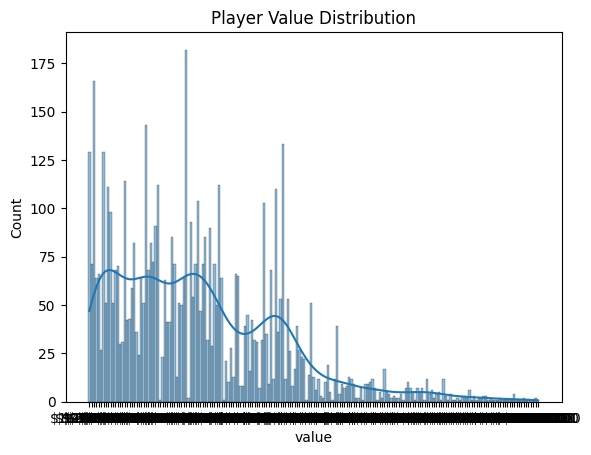

In [22]:
sns.histplot(df['value'], kde=True)
plt.title("Player Value Distribution")
plt.show()

In [25]:
df['value'] = df['value'].replace('[$,.]', '', regex=True).astype(float)
df['value'] = np.log1p(df['value'])

**Bivariate Analysis**

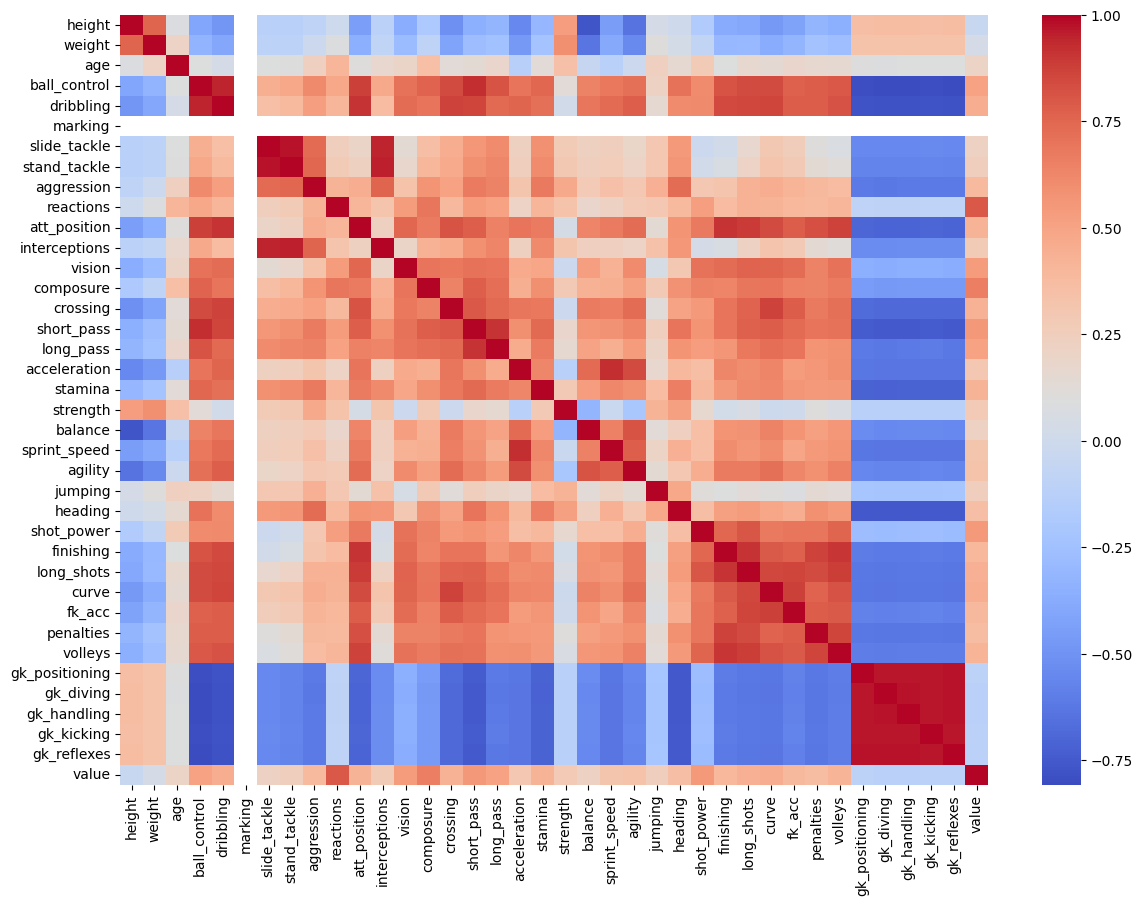

In [26]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

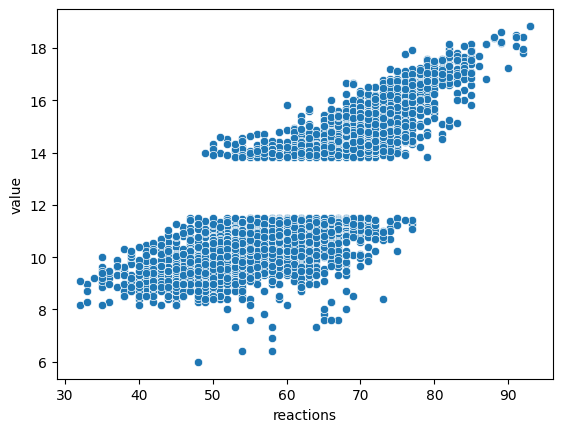

In [28]:
sns.scatterplot(x='reactions', y='value', data=df)
plt.show()

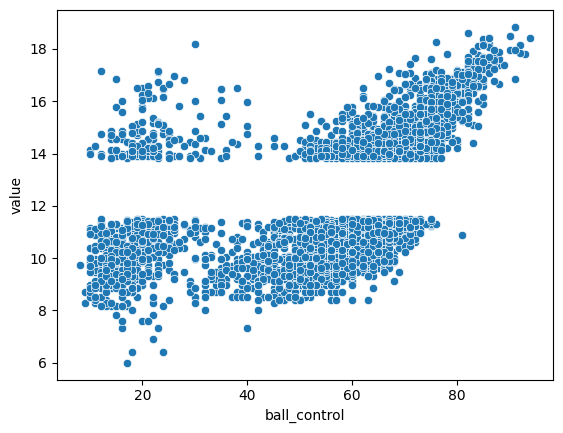

In [29]:
sns.scatterplot(x='ball_control', y='value', data=df)
plt.show()

In [33]:
##Outliers Detection

Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['value'] >= lower) & (df['value'] <= upper)]

In [37]:
le = LabelEncoder() ## Create a new LabelEncoder object

df['country'] = le.fit_transform(df['country'])
df['club'] = le.fit_transform(df['club'])

In [36]:
## Define features and target
X = df.drop("value", axis=1)
y = df["value"]

In [39]:
## Split Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
## Standarization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
##PCA
pca = PCA()

# Find the index of the 'marking' column in the original X dataframe
# (which corresponds to the column in X_train_scaled)
marking_col_index = X.columns.get_loc('marking')

# The 'marking' column was entirely NaN and remained so after imputation (median of NaNs is NaN).
# ML models cannot handle NaN values, so it's explicitly removed here before PCA.
X_train_scaled_cleaned = np.delete(X_train_scaled, marking_col_index, axis=1)

# Apply PCA to the cleaned training data
X_train_pca = pca.fit_transform(X_train_scaled_cleaned)

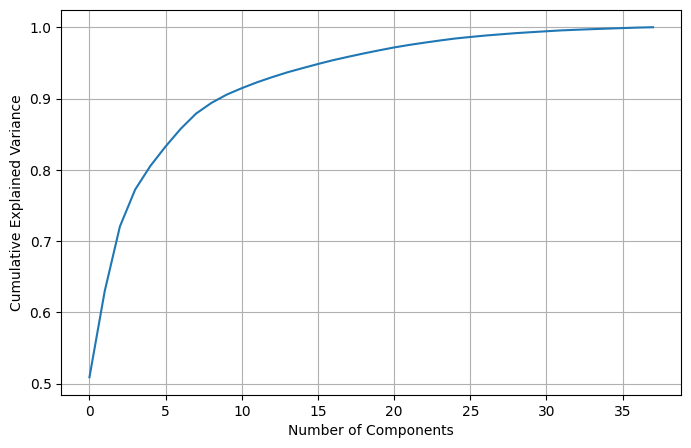

In [43]:
##Vairence Plot
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()
plt.show()

**Model Building**

In [47]:
# Ensure marking_col_index is available (it was defined in the PCA cell)
# If running this cell independently, ensure marking_col_index is defined
if 'marking_col_index' not in locals():
    marking_col_index = X.columns.get_loc('marking')

# The 'marking' column was entirely NaN and remained so after imputation (median of NaNs is NaN).
# ML models cannot handle NaN values, so it's explicitly removed here before Linear Regression.
X_train_scaled_lr = np.delete(X_train_scaled, marking_col_index, axis=1)
X_test_scaled_lr = np.delete(X_test_scaled, marking_col_index, axis=1)

lr = LinearRegression()
lr.fit(X_train_scaled_lr, y_train)

y_pred_lr = lr.predict(X_test_scaled_lr)

In [49]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [52]:
# Evaluate Linear Regression model
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name} - MAE: {mae:.4f}")
    print(f"{model_name} - MSE: {mse:.4f}")
    print(f"{model_name} - R2 Score: {r2:.4f}")

evaluate_model(y_test, y_pred_lr, "Linear Regression")

Linear Regression - MAE: 0.9269
Linear Regression - MSE: 1.3321
Linear Regression - R2 Score: 0.7516


In [56]:
evaluate_model(y_test, y_pred_lr, "Linear Regression")

Linear Regression - MAE: 0.9269
Linear Regression - MSE: 1.3321
Linear Regression - R2 Score: 0.7516


In [55]:
evaluate_model(y_test, y_pred_rf, "Random Forest Regressor")

Random Forest Regressor - MAE: 0.4598
Random Forest Regressor - MSE: 0.4821
Random Forest Regressor - R2 Score: 0.9101


In [57]:
# Prepare test data for PCA (remove 'marking' column and apply PCA transformation)
X_test_scaled_cleaned = np.delete(X_test_scaled, marking_col_index, axis=1)
X_test_pca = pca.transform(X_test_scaled_cleaned)

# Train Linear Regression with PCA
lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)

y_pred_lr_pca = lr_pca.predict(X_test_pca)

# Evaluate Linear Regression with PCA
evaluate_model(y_test, y_pred_lr_pca, "Linear Regression with PCA")

Linear Regression with PCA - MAE: 0.9269
Linear Regression with PCA - MSE: 1.3321
Linear Regression with PCA - R2 Score: 0.7516


In [62]:
##Hyperparameter Tuning using GridsearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

In [63]:
print("Best Parameters: ", grid.best_params_)
y_pred_tuned_rf = best_model.predict(X_test)
evaluate_model(y_test, y_pred_tuned_rf, "Tuned Random Forest Regressor")

Best Parameters:  {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Random Forest Regressor - MAE: 0.4581
Tuned Random Forest Regressor - MSE: 0.4778
Tuned Random Forest Regressor - R2 Score: 0.9109


In [65]:
##Insights
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

reactions        0.591242
ball_control     0.118279
age              0.050380
stand_tackle     0.026652
interceptions    0.022312
slide_tackle     0.019000
dribbling        0.017002
sprint_speed     0.012240
gk_diving        0.011294
gk_reflexes      0.010537
dtype: float64


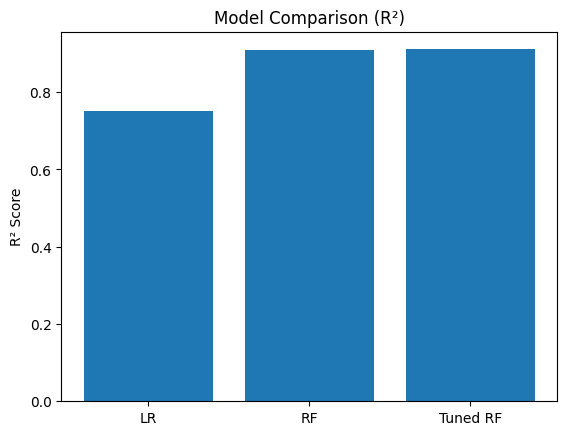

In [68]:
##Visualization
r2_lr = r2_score(y_test, y_pred_lr)
r2_rf = r2_score(y_test, y_pred_rf)
r2_tuned = r2_score(y_test, y_pred_tuned_rf)

models = ['LR', 'RF', 'Tuned RF']
r2_scores = [r2_lr, r2_rf, r2_tuned]

plt.bar(models, r2_scores)
plt.title("Model Comparison (R²)")
plt.ylabel("R² Score")
plt.show()